In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as stats
from joblib import Parallel, delayed

In [2]:
# global fontsize for plots
plt.rcParams.update({'font.size': 15})

In [3]:
# read in historical constituents data
df_stocks = pd.read_csv('sp500.csv')
#convert date columns to pandas dates
df_stocks['start'] = pd.to_datetime(df_stocks['start'], errors='coerce')
df_stocks['ending'] = pd.to_datetime(df_stocks['ending'], errors='coerce')
df_stocks['date'] = pd.to_datetime(df_stocks['date'], errors='coerce')

In [4]:
df_stocks.head()

,date,permno,comnam,ticker,start,ending,ret,prc,shrout,gsector,GICS Sector
0,2000-01-03,14891,UNOCAL CORP,UCL,1957-03-01,2005-08-10,-0.016760,33.0000,242418.0,10.0,Energy
1,2000-01-03,48725,UNION PACIFIC CORP,UNP,1969-07-16,2024-12-31,-0.014306,43.0625,248568.0,20.0,Industrials
2,2000-01-03,24272,ASHLAND INC,ASH,1989-08-03,2008-11-13,-0.028463,32.0000,71291.0,15.0,Materials
3,2000-01-03,22680,MILACRON INC,MZ,1954-04-20,2000-06-28,0.004065,15.4375,37013.0,20.0,Industrials
4,2000-01-03,28222,AIR PRODUCTS & CHEMICALS INC,APD,1985-04-11,2024-12-31,-0.022346,32.8125,229305.0,15.0,Materials


In [5]:
# read in index returns data
df_index = pd.read_csv('spreturns.csv')
# convert date column to pandas dates
df_index['date'] = pd.to_datetime(df_index['date'], errors='coerce')

In [6]:
df_index.head()

,date,sp500_ret
0,2000-01-03,-0.009373
1,2000-01-04,-0.038439
2,2000-01-05,0.000852
3,2000-01-06,-0.002845
4,2000-01-07,0.032193


In [7]:
# function to get previous data for training model
def get_training_data(target_date, lookback, df_stocks, df_index):

    # first time
    t_date = pd.to_datetime(target_date)
    
    # get first date for training data
    # multiply by 1.6 to convert lookback to trading days
    start_date = t_date - pd.Timedelta(days=lookback * 1.6)
    
    # get S&P500 constituents within the training period
    time_mask = (df_stocks['date'] >= start_date) & (df_stocks['date'] < t_date)
    window_df = df_stocks.loc[time_mask].copy()
    
    # filter only stocks who are in the index on t_date
    sp_mask = ((window_df['start'] <= t_date) & ((window_df['ending'] >= t_date) | (window_df['ending'].isna())))
    
    # get current stocks by permno 
    valid_permnos = window_df.loc[sp_mask, 'permno'].unique()
    
    # construct matrix, dates as rows, permnos as cols, returns as the values
    X = window_df[window_df['permno'].isin(valid_permnos)].pivot(index='date', columns='permno', values='ret')
    
    # get historical S&P500 returns and match up to corresponding entries in matrix above
    y = df_index[(df_index['date'] >= X.index.min()) & (df_index['date'] <= X.index.max())]
    y = y.set_index('date')['sp500_ret']
    
    common_dates = X.index.intersection(y.index)
    X = X.loc[common_dates]
    y = y.loc[common_dates]
    
    # if a stock does not have full data for the whole training period, do not include it
    X = X.dropna(axis=1, how='any')
    X = X.fillna(0.0)
    
    # trim to the exact length needed
    X = X.tail(lookback)
    y = y.tail(lookback)
    
    return X, y

In [8]:
# function to generate the weights of a sparse portfolio with target_n stocks
# uses the returns from above function
def optimise_portfolio_target_n(X, y, target_n, iterations=30):
    n_features = X.shape[1]
    
    # if target_n is almost all constituents, skip Lasso, straight to OLS
    if target_n >= n_features * 0.95:
        model = LinearRegression(positive=True, fit_intercept=True)
        model.fit(X, y)
        return pd.Series(model.coef_, index=X.columns)

    # set range of parameter values for Lasso for the binary search
    low_alpha = 1e-10
    high_alpha = 1.0
    # tracking variables for the best weights
    best_weights = None
    best_dist = float('inf')
    
    # binary search, adjust penalty parameter until target_n number of stocks is reached
    for i in range(iterations): 
        mid_alpha = (low_alpha + high_alpha) / 2
        
        # fit Lasso model,
        model = Lasso(alpha=mid_alpha, positive=True, fit_intercept=True, max_iter=50000, tol=1e-4)
        model.fit(X, y)
        
        n_selected = (model.coef_ > 1e-5).sum()
        
        # save best result so far
        if abs(n_selected - target_n) < best_dist:
            best_dist = abs(n_selected - target_n)
            best_weights = model.coef_
            
        # binary search
        if n_selected > target_n:
            low_alpha = mid_alpha
        else:
            high_alpha = mid_alpha
    
    # safety net to stop crashes
    if best_weights is None:
        best_weights = pd.Series(0, index=X.columns)
    
    # get the active weights
    selected_mask = best_weights > 1e-5

    # if nothing selected, return empty
    if selected_mask.sum() == 0: 
        return pd.Series(0.0, index=X.columns)
    
    # subset of the active stocks in the portfolio identified by Lasso
    X_subset = X.loc[:, selected_mask]
    
    # OLS on the chosen subset
    ols = LinearRegression(positive=True, fit_intercept=True)
    ols.fit(X_subset, y)
    
    final_weights = pd.Series(0.0, index=X.columns)
    final_weights[selected_mask] = ols.coef_
    
    return final_weights

In [9]:
TRAINING_YEARS = 2
LOOKBACK_DAYS = TRAINING_YEARS * 252 # 252 trading days in a year

# use the maximum possible amount of available data
start_date = df_stocks['date'].min() + pd.DateOffset(years=TRAINING_YEARS)
end_date = df_stocks['date'].max()

In [10]:
# helper function for generating weights and testing until the next rebalancing date
# same code as usual
def process_single_period(date, freq_code):
    str_date = date.strftime('%Y-%m-%d')
    
    # get data
    X_train, y_train = get_training_data(str_date, LOOKBACK_DAYS, df_stocks, df_index)
    
    # if X_train.empty or y_train.empty or X_train.shape[0] < 10 or X_train.shape[1] == 0:
    #     return date, None, None
        
    # run Lasso regression, use default target N=150 stocks
    weights = optimise_portfolio_target_n(X_train, y_train, target_n=150)
    
    # determine next rebalance date 
    if freq_code == 'YS':
        next_rebalance = date + pd.DateOffset(years=1)
    elif freq_code == 'QS':
        next_rebalance = date + pd.DateOffset(months=3)
    elif freq_code == 'MS':
        next_rebalance = date + pd.DateOffset(months=1)
    elif freq_code == 'B':
        next_rebalance = date + pd.offsets.BDay(1) # Next trading day
    
    # get the next chunk of data to test portfolio
    mask_test = (df_stocks['date'] >= date) & (df_stocks['date'] < next_rebalance)
    test_df = df_stocks.loc[mask_test]
    
    if test_df.empty: 
        return date, weights, None
    
    # create test matrix, dates as rows, permnos as cols, returns as the values
    X_test = test_df.pivot(index='date', columns='permno', values='ret').fillna(0.0)
    # if a stock delists, we assume return is 0 for remainder
    # columns=weights.index so only testing on stocks currently in the index
    X_test = X_test.reindex(columns=weights.index, fill_value=0.0)

    # dates x stocks  @  stocks x weights  =  dates x portfolio return
    period_ret = X_test.dot(weights)
    
    return date, weights, period_ret

In [11]:
# test the model with different frequencies of recalculating weights
frequencies = {
    'Annual': 'YS',
    'Quarterly': 'QS',
    'Monthly': 'MS',
    'Daily': 'B'
}

# storage for results
results_table = {'Frequency': [], 'Tracking Error': [], 'Turnover': []}


for freq_name, freq_code in frequencies.items():
    print(f"\nTesting {freq_name} Rebalancing", end="\n")

    # compute range of dates for each frequency
    dates = pd.date_range(start=start_date, end=end_date, freq=freq_code)

    # run in parallel (n_jobs=-1 uses all the CPU cores)
    # use threading to prevent copying dataframes and using all the RAM
    raw_results = Parallel(n_jobs=-1, backend="threading")(
        delayed(process_single_period)(d, freq_code) for d in dates
    )
    
    # sort results chronologically in case a CPU finished out of order
    raw_results = sorted(raw_results, key=lambda x: x[0])
    
    # track results for this frequency
    all_period_returns = []
    total_turnover = 0.0
    # keep track of previous weights to calculate turnover in rebalancing to new weights
    prev_weights = None
    
    for date, weights, period_ret in raw_results:
        if weights is None: continue
            
        # calculate turnover sequentially
        if prev_weights is None:
            current_turnover = 0.0
        else:
            # get all stocks in old and new weights
            all_assets = weights.index.union(prev_weights.index)
            # index by full list
            w_curr = weights.reindex(all_assets, fill_value=0.0)
            w_prev = prev_weights.reindex(all_assets, fill_value=0.0)
            # calculate turnover by finding absolute difference
            current_turnover = (w_curr - w_prev).abs().sum()
        
        # update
        total_turnover += current_turnover
        prev_weights = weights
        
        if period_ret is not None:
            all_period_returns.append(period_ret)


    # get sparse portfolio returns history for this frequency
    full_series = pd.concat(all_period_returns)
    # get index returns history for the same dates
    idx_series = df_index.set_index('date')['sp500_ret'].loc[full_series.index]
    
    # calculate tracking error
    diff = full_series - idx_series
    # multiply by sqrt(252) to annualise the value
    te = diff.std() * np.sqrt(252)

    # compute stats year by year instead of for the whole period
    yearly_stats = pd.DataFrame()
    yearly_stats['Tracking Error'] = diff.groupby(diff.index.year).apply(lambda x: x.std() * np.sqrt(252))

    # calculate number of years the backtest went through and compute annualised turnover
    n_years_sim = (dates[-1] - dates[0]).days / 365.25
    ann_turnover = total_turnover / n_years_sim
    
    results_table['Frequency'].append(freq_name)
    results_table['Tracking Error'].append(te)
    results_table['Turnover'].append(ann_turnover)
    
    print(f"Annualised Tracking Error: {te:.4%} | Turnover: {ann_turnover:.2f}x/yr")


Testing Annual Rebalancing
Annualised Tracking Error: 2.3185% | Turnover: 0.83x/yr

Testing Quarterly Rebalancing
Annualised Tracking Error: 2.1216% | Turnover: 2.03x/yr

Testing Monthly Rebalancing
Annualised Tracking Error: 1.9227% | Turnover: 3.96x/yr

Testing Daily Rebalancing
Annualised Tracking Error: 1.8049% | Turnover: 24.72x/yr


In [12]:
# divide by 2 to account for buying and selling double counting
for turnover in results_table['Turnover']:
    print(f"Average Annual Portfolio Turnover: {turnover / 2:.3f}x/yr")

Average Annual Portfolio Turnover: 0.416x/yr
Average Annual Portfolio Turnover: 1.017x/yr
Average Annual Portfolio Turnover: 1.980x/yr
Average Annual Portfolio Turnover: 12.358x/yr


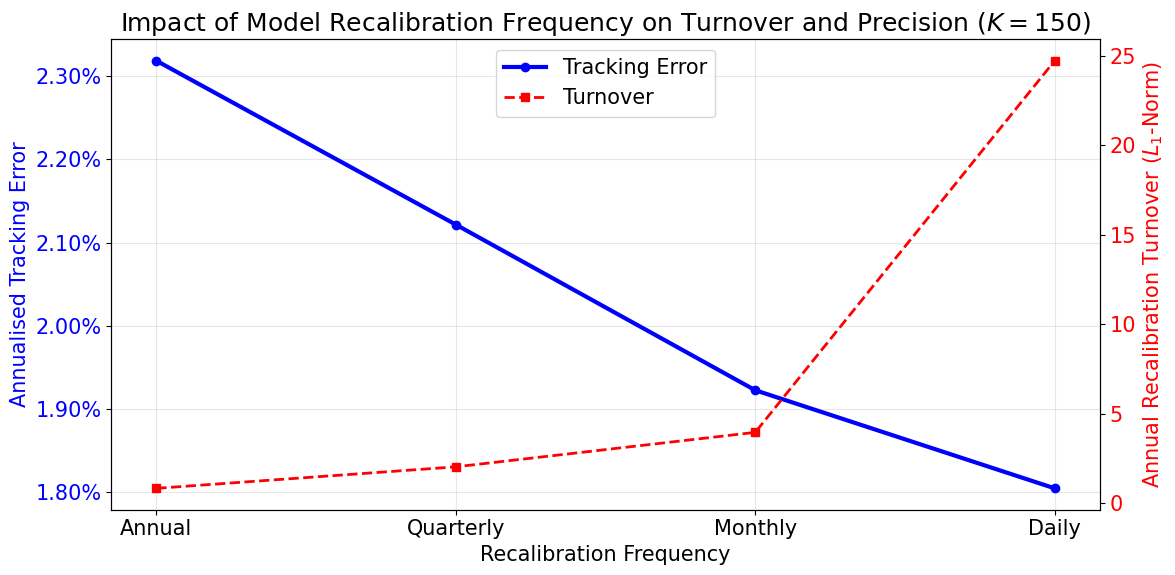

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# plot tracking error left axis
ax1.set_xlabel('Recalibration Frequency')
ax1.set_ylabel('Annualised Tracking Error', color='blue')
line1 = ax1.plot(results_table['Frequency'], results_table['Tracking Error'], marker='o', color='blue', linewidth=3, label='Tracking Error')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.grid(True, alpha=0.3)

# plot turnover right axis
ax2 = ax1.twinx()
ax2.set_ylabel('Annual Recalibration Turnover ($L_1$-Norm)', color='red')
line2 = ax2.plot(results_table['Frequency'], results_table['Turnover'], marker='s', linestyle='--', color='red', linewidth=2, label='Turnover')
ax2.tick_params(axis='y', labelcolor='red')

# combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title('Impact of Model Recalibration Frequency on Turnover and Precision ($K=150$)')
plt.tight_layout()
plt.show()